# SDR Linkbudget (Mess- und Rechenaufgabe)

Ziel:
- Träger um 433 MHz messen
- Empfangsleistung mit Kalibrierung: `../03_02_LABOR-2/submissions/calibration.json`
- bei 0 dBi Sende-/Empfangsantenne: C/N0 und effektive Rauschtemperatur ableiten
- Freiraumdaempfung (LOS) berechnen und mit Messwert vergleichen (Multipath-Indiz)

## 433 MHz ISM-band Transmitter  

[Lieferhinweis: zusammen mit 433MHz Empfänger bei amazon](https://www.amazon.de/dp/B07DJ2ZJXR/ref=sspa_dk_detail_2?psc=1&pd_rd_i=B07DJ2ZJXR&pd_rd_w=dq012&content-id=amzn1.sym.bf6dbf94-e926-4351-8952-c09f45cdef70&pf_rd_p=bf6dbf94-e926-4351-8952-c09f45cdef70&pf_rd_r=NXS6V765Z9Q7V9TQMCZT&pd_rd_wg=Llrmy&pd_rd_r=bfd4df50-a70b-4a80-a704-915513bb08c0&aref=xSZ1IpJDBY&sp_csd=d2lkZ2V0TmFtZT1zcF9kZXRhaWw)  

![](media/ISM-433-tx.jpg)

Das 433MHz ISM-band Sendemodul liefert bei ca. 433.8 MHz eine Sendeleistung von knapp 0dBm, mit einem 10dB-Abschwächer wird die Sendeleistung auf -11dBm begrenzt.  
Versorgt wird das Modul mit einem 3.3V-Netzteil. Der Sender wird über einen digitalen Eingang ein- und ausgeschaltet, und kann so ASK-moduliert werden, die erzielbare Datenrate ist wenige kbit/s. Für diese Messung wird der Datenpin permanent mit 3.3V versorgt, was zu einem unmodulierten Träger führt.


In [4]:
import os
import json
import math
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np


def find_task_root(start: Optional[Path] = None) -> Path:
    """Ordner des aktuellen Labs (03_03_LABOR-3), egal ob cwd = Lab oder submissions/."""
    p = (start or Path.cwd()).resolve()
    for d in [p, *p.parents]:
        if (d / "submissions").is_dir():
            return d
    return p


def is_instructor_mode(task_root: Path) -> bool:
    lab_suite = task_root.parent.parent
    key = lab_suite / ".instructor_key"
    try:
        return key.is_file() and key.stat().st_size > 0
    except OSError:
        return False


def resolve_calibration_path(task_root: Path) -> Path:
    labor2 = task_root.parent / "03_02_LABOR-2"
    student_cal = labor2 / "submissions" / "calibration.json"
    instructor_cal = labor2 / "calibration.json"
    if student_cal.is_file():
        return student_cal
    if is_instructor_mode(task_root) and instructor_cal.is_file():
        return instructor_cal
    return student_cal


LAB_DIR = find_task_root()
CAL_PATH = resolve_calibration_path(LAB_DIR)

# RTL-SDR DLL-Ordner suchen (analog zu rtl_sdr_sliders.ipynb)
_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: rtl-sdr-driver (librtlsdr.dll) nicht gefunden.")

CENTER_FREQ_HZ = 434.0e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20
N = 4096
M = 32  # genau 32 Bloecke

# Record/Replay: REPLAY=True -> IQ aus JSON laden, REPLAY=False -> neu messen und speichern
REPLAY = False
REPLAY_FILE = Path("recordings") / "sdr_linkbudget_replay.json"

# Bekannt gegebene Sendeleistung (anpassen falls noetig)
TX_POWER_DBM = -11.0 # tx power in dBm

# Geschaetzter LOS-Abstand (fuer Vergleich mit gemessener Linkdaempfung)
DIST_GUESS_M = 5.0 # distance in meter

print("Calibration file:", CAL_PATH)
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

RTL-SDR Treiber gefunden: C:\_Git\KT-course\rtl-sdr-driver
Calibration file: C:\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration.json
REPLAY=False, Datei=recordings\sdr_linkbudget_replay.json


In [5]:
def load_calibration(path: Path) -> dict:
    data = json.loads(path.read_text(encoding="utf-8"))
    return data

def get_cal_offset_db(cal: dict, gain_db: float) -> float:
    gains = cal.get("gains", [])
    if not gains:
        raise ValueError("No gains in calibration file")
    best = min(gains, key=lambda g: abs(float(g["gain_dB"]) - float(gain_db)))
    return float(best["calibration_offset_dB"])

def capture_iq_or_fallback(center_hz: float, fs_hz: float, gain_db: float, total_samples: int) -> np.ndarray:
    try:
        from rtlsdr import RtlSdr
        sdr = RtlSdr()
        sdr.sample_rate = fs_hz
        sdr.center_freq = center_hz
        sdr.gain = gain_db
        iq = sdr.read_samples(total_samples)
        sdr.close()
        return np.asarray(iq, dtype=np.complex64)
    except Exception as ex:
        print("RTL-SDR nicht verfuegbar, nutze synthetischen Fallback:", ex)
        t = np.arange(total_samples, dtype=np.float64) / fs_hz
        tone_off_hz = 70e3
        tone = 0.08 * np.exp(1j * 2 * np.pi * tone_off_hz * t)
        noise = (np.random.randn(total_samples) + 1j * np.random.randn(total_samples)) * 0.01
        return (tone + noise).astype(np.complex64)

def avg_spectrum(iq: np.ndarray, fs_hz: float, nfft: int, m_avg: int):
    need = nfft * m_avg
    if iq.size < need:
        raise ValueError(f"Need {need} samples, got {iq.size}")
    x = iq[:need].reshape(m_avg, nfft)
    win = np.hanning(nfft).astype(np.float64)
    spec = np.fft.fftshift(np.fft.fft(x * win, axis=1), axes=1)
    mag = np.mean(np.abs(spec), axis=0)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-15))
    f_rel = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0 / fs_hz))
    return f_rel, mag_db

def estimate_noise_db(mag_db: np.ndarray, peak_idx: int, guard: int = 4) -> float:
    mask = np.ones_like(mag_db, dtype=bool)
    lo = max(0, peak_idx - guard)
    hi = min(mag_db.size, peak_idx + guard + 1)
    mask[lo:hi] = False
    return float(np.median(mag_db[mask]))


def save_replay_iq(path: Path, iq: np.ndarray, fs_hz: float, center_hz: float, gain_db: float, n: int, m: int):
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {
        "meta": {"type": "sdr_linkbudget_iq", "version": 1},
        "sample_rate_hz": fs_hz,
        "center_freq_hz": center_hz,
        "gain_db": gain_db,
        "N": n,
        "M": m,
        "iq_re": np.real(iq).astype(float).tolist(),
        "iq_im": np.imag(iq).astype(float).tolist(),
    }
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_iq(path: Path) -> np.ndarray:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    data = json.loads(path.read_text(encoding="utf-8"))
    re = np.asarray(data["iq_re"], dtype=np.float32)
    im = np.asarray(data["iq_im"], dtype=np.float32)
    if re.size != im.size:
        raise ValueError("Replay-Datei ungueltig: iq_re und iq_im unterschiedlich lang")
    return (re + 1j * im).astype(np.complex64)

In [6]:
cal = load_calibration(CAL_PATH)
cal_offset_db = get_cal_offset_db(cal, GAIN_DB)

total_samples = N * M
if REPLAY:
    iq = load_replay_iq(REPLAY_FILE)
    if iq.size < total_samples:
        raise RuntimeError(f"Replay-IQ zu kurz: {iq.size} < {total_samples}")
    iq = iq[:total_samples]
    print("Replay-IQ geladen:", REPLAY_FILE)
else:
    iq = capture_iq_or_fallback(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, total_samples)
    if iq.size < total_samples:
        raise RuntimeError(f"Zu wenige IQ-Samples: {iq.size} < {total_samples}")
    iq = iq[:total_samples]
    save_replay_iq(REPLAY_FILE, iq, SAMPLE_RATE_HZ, CENTER_FREQ_HZ, GAIN_DB, N, M)
    print("Replay-IQ gespeichert:", REPLAY_FILE)

f_rel_hz, mag_db_raw = avg_spectrum(iq, SAMPLE_RATE_HZ, N, M)

peak_idx = int(np.argmax(mag_db_raw))
carrier_off_hz = float(f_rel_hz[peak_idx])
carrier_freq_hz = CENTER_FREQ_HZ + carrier_off_hz

rx_power_dbm = float(mag_db_raw[peak_idx] + cal_offset_db)
noise_bin_dbm = estimate_noise_db(mag_db_raw, peak_idx, guard=4) + cal_offset_db

# TODO
bin_bw_hz = SAMPLE_RATE_HZ / N  # [Hz] Bandbreite pro FFT-Bin, Hinweis: berücksichtige die sample-rate und die FFT-Länge N (ergibt die Dauer der Fourieranalyse, damit die "Breite" eines bins)

# TODO
n0_dbm_hz = noise_bin_dbm - 10 * np.log10(bin_bw_hz)  # [dBm/Hz] Rauschleistungsdichte N0 , Hinweis: teile die durchschittliche Leistung (noise_bin_dbm) des gemessenen Noise-Floors durch die bin_bw_hz

# TODO
cn0_db_hz = rx_power_dbm - n0_dbm_hz # [dB-Hz] Carrier-to-Noise-Density, Hinweis: Verhältnis des Träger-Peaks zur Noise-Leistung pro Hz

# TODO
k_boltzmann = 1.380649e-23
n0_linear_watt_per_hz = 10**((n0_dbm_hz - 30) / 10.0)
t_eff_k = n0_linear_watt_per_hz / k_boltzmann  # [K] effektive Rauschtemperatur, Hinweis: aus der Formel N = k . T. B    k= 1.38e-23 J/K ... Boltzmann Konstante

c0 = 299_792_458.0

# TODO
wavelength_m = c0 / carrier_freq_hz # [m] Wellenlaenge

# TODO
fspl_meas_db = TX_POWER_DBM - rx_power_dbm  # [dB] aus Messung abgeleitete Daempfung, Hinweis: free space loss aus Verhältnis Empfangs- zu Sendelseistung

# TODO
fspl_constant = 20 * np.log10(carrier_freq_hz) + 20 * np.log10(4 * np.pi / c0)
d_from_meas_m = 10**((fspl_meas_db - fspl_constant) / 20.0)  # [m] aus FSPL rueckgerechneter Abstand, Hinweis: welcher LOS-Abstand würde auf die ermittelte Dämpfung führen?

# TODO
fspl_guess_db = 20 * np.log10(DIST_GUESS_M) + fspl_constant  # [dB] theoretische LOS-FSPL beim geschaetzten Abstand, Hinweis: das wäre die tatsächliche LOS (Line-of-Sight) Dämpfung für den geschätzten Abstand Sender-Empfänger.

# Vorschlag: multipath_delta_db = fspl_meas_db - fspl_guess_db
multipath_delta_db = fspl_meas_db - fspl_guess_db  # [dB] Abweichung Messung vs. LOS-Schaetzung


print(f"Carrier freq      : {carrier_freq_hz/1e6:.6f} MHz")
print(f"RX power          : {rx_power_dbm:.2f} dBm")
print(f"Noise density N0  : {n0_dbm_hz:.2f} dBm/Hz")
print(f"C/N0              : {cn0_db_hz:.2f} dB-Hz")
print(f"T_eff             : {t_eff_k:.1f} K")
print(f"Wavelength        : {wavelength_m:.4f} m")
print(f"FSPL (measured)   : {fspl_meas_db:.2f} dB")
print(f"Distance from FSPL: {d_from_meas_m:.1f} m")
print(f"Estimated distance: {DIST_GUESS_M:.1f} m")
print(f"FSPL (guess LOS)  : {fspl_guess_db:.2f} dB @ d={DIST_GUESS_M:.1f} m")
print(f"Delta (meas-guess): {multipath_delta_db:+.2f} dB")

RTL-SDR nicht verfuegbar, nutze synthetischen Fallback: <LIBUSB_ERROR_IO (-1): Input/output error> "Could not open SDR (device index = 0)"
Replay-IQ gespeichert: recordings\sdr_linkbudget_replay.json
Carrier freq      : 434.070000 MHz
RX power          : -71.93 dBm
Noise density N0  : -149.40 dBm/Hz
C/N0              : 77.47 dB-Hz
T_eff             : 83174.4 K
Wavelength        : 0.6907 m
FSPL (measured)   : 60.93 dB
Distance from FSPL: 61.2 m
Estimated distance: 5.0 m
FSPL (guess LOS)  : 39.18 dB @ d=5.0 m
Delta (meas-guess): +21.75 dB


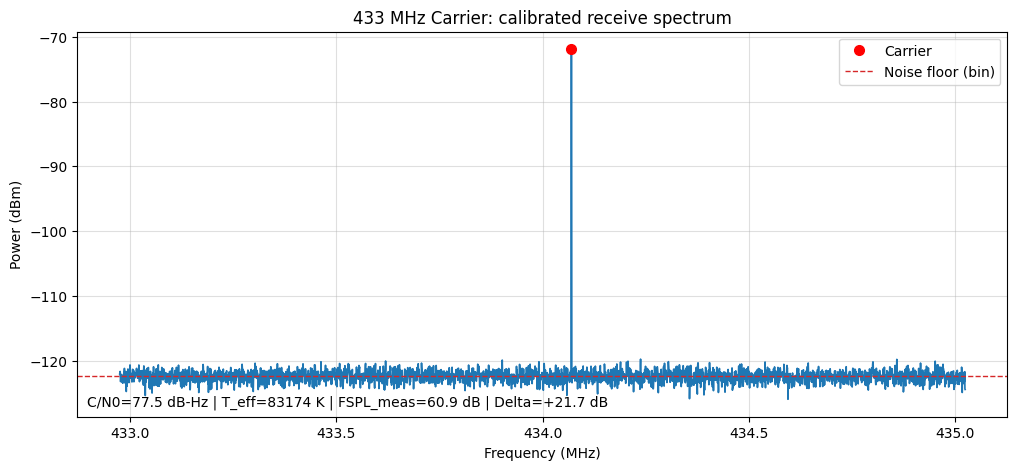

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
f_mhz = (CENTER_FREQ_HZ + f_rel_hz) / 1e6
ax.plot(f_mhz, mag_db_raw + cal_offset_db, lw=1.2, color="C0")
ax.plot([carrier_freq_hz/1e6], [rx_power_dbm], "o", color="red", ms=7, label="Carrier")
ax.axhline(noise_bin_dbm, color="C3", ls="--", lw=1.0, label="Noise floor (bin)")
ax.set_title("433 MHz Carrier: calibrated receive spectrum")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Power (dBm)")
ax.grid(True, alpha=0.4)
ax.legend(loc="best")
ax.text(
    0.01, 0.02,
    f"C/N0={cn0_db_hz:.1f} dB-Hz | T_eff={t_eff_k:.0f} K | FSPL_meas={fspl_meas_db:.1f} dB | Delta={multipath_delta_db:+.1f} dB",
    transform=ax.transAxes,
    ha="left", va="bottom", fontsize=10,
)
plt.show()